#Google Drive Mount

In [ ]:
# prompt: mount google drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Pseudocode Extraction



In [ ]:
import nbformat
import re

# Path to the Jupyter Notebook
path_to_notebook = "/content/drive/MyDrive/work2/Code/Models Evaluations.ipynb"

# Load the notebook
with open(path_to_notebook, 'r', encoding='utf-8') as f:
    notebook = nbformat.read(f, as_version=4)

# Function to generate pseudocode

def generate_pseudocode(cell_content):
    """
    Generate a simplified pseudocode from Python code.
    """
    pseudocode = []

    # Extract significant lines while removing Python-specific syntax
    for line in cell_content.splitlines():
        line = line.strip()
        if line.startswith("#"):
            # Include comments as is
            pseudocode.append(line)
        elif re.match(r'(def |class |if |for |while |import |return)', line):
            # Keep logical structures, functions, loops, imports
            pseudocode.append(line)
        elif re.match(r'(print|assert|break|continue|pass)', line):
            # Keep essential commands
            pseudocode.append(line)

    return "\n".join(pseudocode)

# Extract pseudocode from selected cells
pseudocode_list = []
cell_index = 0

for cell in notebook['cells']:
    if cell['cell_type'] == 'code':
        cell_index += 1
        pseudocode = generate_pseudocode(cell['source'])
        pseudocode_list.append(f"\n--- Cell {cell_index} Pseudocode ---\n{pseudocode}")

# Save pseudocode to a file
pseudocode_path = "/content/drive/MyDrive/work2/Code/Models_Evaluations_Pseudocode.txt"
with open(pseudocode_path, 'w', encoding='utf-8') as pseudocode_file:
    pseudocode_file.write("\n\n".join(pseudocode_list))

print(f"Pseudocode for the notebook has been saved to: {pseudocode_path}")

Pseudocode for the notebook has been saved to: /content/drive/MyDrive/work2/Code/Models_Evaluations_Pseudocode.txt


#Copying Frames

In [ ]:
import shutil
import os

# Source and destination paths
src = '/content/drive/MyDrive/work2/Frames'
dst = '/content/drive/MyDrive/work2/Final/Frames'

# Create destination folder if it doesn't exist
os.makedirs(dst, exist_ok=True)

# Copy the entire directory
shutil.copytree(src, dst, dirs_exist_ok=True)

print(f"Copied {src} to {dst}")


Copied /content/drive/MyDrive/work2/Frames to /content/drive/MyDrive/work2/Final/Frames


In [ ]:
import cv2
import pandas as pd
import os

# Function to extract frames
def extract_frames(video_file_path, times_in_seconds, output_folder):
    video_name = os.path.basename(video_file_path).split('.')[0]
    cap = cv2.VideoCapture(video_file_path)
    frame_info = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        current_time = int(cap.get(cv2.CAP_PROP_POS_MSEC) // 1000)
        if current_time in times_in_seconds:
            frame_filename = os.path.join(output_folder, f'{video_name}_frame_{current_time}.jpg')
            cv2.imwrite(frame_filename, frame)
            frame_info.append({'Video Name': video_name, 'Frame Path': frame_filename, 'Time in Seconds': current_time})
            times_in_seconds.remove(current_time)
    cap.release()
    return frame_info

# Directory containing videos
video_directory = '/content/drive/MyDrive/work2/videos'
output_base_folder = '/content/drive/MyDrive/work2/Final/Frames'

# Load positions from the CSV file
csv_file_path = '/content/drive/MyDrive/work2/Final/transcription_results_final.csv'
df = pd.read_csv(csv_file_path)

# Convert positions to lists of integers
df['negative_positions'] = df['negative_positions'].apply(lambda x: eval(x))
df['positive_positions'] = df['positive_positions'].apply(lambda x: eval(x))

all_frame_info = []  # Store info for all frames from all videos

# Process each video file
for video_file in os.listdir(video_directory):
    video_file_path = os.path.join(video_directory, video_file)
    video_name = os.path.splitext(video_file)[0]
    video_df = df[df['audio_name'].str.contains(video_name)]

    # Concatenate, flatten, and remove duplicates from positions
    all_positions = video_df['negative_positions'].tolist() + video_df['positive_positions'].tolist()
    times_in_seconds = list(set([int(time) for sublist in all_positions for time in sublist]))

    # Create output folder for this video
    output_folder = os.path.join(output_base_folder, video_name)
    os.makedirs(output_folder, exist_ok=True)

    # Extract frames
    frame_info = extract_frames(video_file_path, times_in_seconds, output_folder)
    all_frame_info.extend(frame_info)

# Save frame information to a new CSV file
frames_csv_path = '/content/drive/MyDrive/work2/Final/extracted_frames_info.csv'
frame_info_df = pd.DataFrame(all_frame_info)
frame_info_df.to_csv(frames_csv_path, index=False)

print("Frames extracted and saved.")
print(f"Frame information saved to {frames_csv_path}")


Frames extracted and saved.
Frame information saved to /content/drive/MyDrive/work2/Final/extracted_frames_info.csv


#Models Evaluation Start From Here

# 1. Frame Model 2 (Video_Model_2_random_forest_model) Test 30%

In [ ]:
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from skimage.feature import hog
import joblib
import os

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128, 128))
    img = cv2.equalizeHist(img)
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# Extract HOG features from the images
hog_features = [hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys') for image in images]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.3, random_state=42)

# Load the saved model
joblib_file = "/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl"
loaded_rf_model = joblib.load(joblib_file)

# Evaluate the model
y_pred = loaded_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['Random Forest'],
    'Model Path': [joblib_file],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Save the DataFrame to a CSV file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Test accuracy: 64.31%
Precision: 0.64
Recall: 0.64
F1 Score: 0.64
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


In [ ]:
pip install scikit-learn==1.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 39.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.0
    Uninstalling scikit-learn-1.6.0:
      Successfully uninstalled scikit-learn-1.6.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.3 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from skimage.feature import hog
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128, 128))
    img = cv2.equalizeHist(img)
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# Extract HOG features from the images
hog_features = [hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys') for image in images]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.3, random_state=42)

# Load the saved model
joblib_file = "/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl"
loaded_rf_model = joblib.load(joblib_file)

# Predict on the test set
y_pred = loaded_rf_model.predict(X_test)

# Calculate and print the error rate
error_rate = 1 - accuracy_score(y_test, y_pred)
print(f"Overall Error Rate: {error_rate:.2%}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
print("\nConfusion Matrix:")
print(conf_matrix)

# Identify specific misclassifications
class_labels = ['Neutral', 'Positive', 'Negative']  # Replace with your actual class names
confusion_details = {}

for i, true_class in enumerate(class_labels):
    for j, predicted_class in enumerate(class_labels):
        if i != j:  # Only consider misclassifications
            confusion_details[f"{true_class} -> {predicted_class}"] = conf_matrix[i, j]

# Print misclassification rates
print("\nMisclassification Details:")
for misclassification, count in confusion_details.items():
    rate = (count / np.sum(conf_matrix)) * 100
    print(f"{misclassification}: {count} instances ({rate:.2f}%)")

# Classification report (optional for detailed breakdown)
class_report = classification_report(y_test, y_pred, target_names=class_labels)
print("\nClassification Report:")
print(class_report)


File not found: /content/drive/MyDrive/work2/Final/Frames/2/2_frame_2.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/3/3_frame_7.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/3/3_frame_19.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/3/3_frame_23.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/3/3_frame_25.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/3/3_frame_6.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/3/3_frame_15.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/3/3_frame_22.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/4/4_frame_8.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/4/4_frame_15.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/4/4_frame_17.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/5/5_frame_6.jpg
File not found: /content/drive/MyDrive/work2/Final/Frames/5/5_frame_18.jpg
File not found: /content/drive

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from skimage.feature import hog
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128, 128))
    img = cv2.equalizeHist(img)
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# Extract HOG features from the images
hog_features = [hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys') for image in images]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.3, random_state=42)

# Load the saved model
joblib_file = "/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl"
loaded_rf_model = joblib.load(joblib_file)

# Evaluate the model
y_pred = loaded_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Generate a classification report
class_report = classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative'])
print("\nClassification Report:")
print(class_report)

# Calculate and display the error rate
error_rate = 1 - accuracy
print(f"\nError Rate: {error_rate:.2%}")

# Generate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Neutral', 'Positive', 'Negative'], yticklabels=['Neutral', 'Positive', 'Negative'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head()


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.643123,0.644568,0.643123,0.643094


#2. Frame Model 1 (Video_Model_1_CNN_with_MobileNetV2) Test 20%

In [ ]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical
import os

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))  # Resize to match MobileNetV2 input
    img = preprocess_input(img)  # Preprocess as per MobileNetV2 requirements
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# One-hot encode labels for categorical crossentropy
labels = to_categorical(labels, num_classes=3)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Load the saved TensorFlow model
model_path = '/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_1_CNN_with_MobileNetV2.h5'
loaded_model = tf.keras.models.load_model(model_path)

# Evaluate the loaded model
test_loss, test_accuracy = loaded_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Make predictions
y_pred_prob = loaded_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['MobileNetV2'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


6/6 [==============================] - 19s 3s/step - loss: 1.0868 - accuracy: 0.6536
Test Loss: 1.0867706537246704, Test Accuracy: 0.6536312699317932
6/6 [==============================] - 12s 2s/step
Accuracy: 65.36%
Precision: 0.65
Recall: 0.65
F1 Score: 0.65
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head()


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.643123,0.644568,0.643123,0.643094
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066


###3. Audio Model 1 (Audio_Model_1_LSTM)

@@ NEW @@

In [ ]:
import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models
import os
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to extract features from audio files
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    energy_contour = librosa.feature.rms(y=y)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    features = np.concatenate((
        np.mean(mfccs, axis=1),
        np.mean(mel, axis=1),
        np.mean(contrast, axis=1),
        np.mean(bandwidth, axis=1),
        np.mean(energy_contour, axis=1),
        np.mean(spectral_rolloff, axis=1)
    ))
    return features

# Folder containing audio files
audio_folder = '/content/drive/MyDrive/work2_extra/wav'

# List to store audio file paths and sentiment labels
file_names = []
senti_values = []

# Iterate through files in the folder
for file_name in os.listdir(audio_folder):
    if os.path.isfile(os.path.join(audio_folder, file_name)):
        file_names.append(os.path.join(audio_folder, file_name))

# Load sentiment labels from a CSV file
csv_path = '/content/drive/MyDrive/work2/Meta_Data/Audio.csv'
df = pd.read_csv(csv_path)
senti_values = df['Senti'].tolist()

# Create a dataset (X, y) with features and labels
X = np.array([extract_features(path) for path in file_names])
y = np.array(senti_values)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Check label distribution
unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

# FIX 1: Proper three-way split to avoid data leakage
# First split: Separate train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Second split: Split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Standardize the features using only training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit only on training data
X_val_scaled = scaler.transform(X_val)          # Transform validation data
X_test_scaled = scaler.transform(X_test)        # Transform test data

# Save the scaler for later use
scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/scaler_lstm.pkl'
joblib.dump(scaler, scaler_path)
print("Scaler saved successfully")

# Reshape for LSTM input
X_train_reshaped = np.expand_dims(X_train_scaled, -1)
X_val_reshaped = np.expand_dims(X_val_scaled, -1)
X_test_reshaped = np.expand_dims(X_test_scaled, -1)

# Define early stopping and model checkpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5',
                             monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# Build a neural network model with LSTM layers
model = models.Sequential()
model.add(layers.LSTM(128, return_sequences=True, input_shape=(X_train_reshaped.shape[1], 1)))
model.add(layers.LSTM(64))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(np.unique(y)), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# FIX 2: Train using validation set instead of test set
print("Training model with proper validation set...")
history = model.fit(X_train_reshaped, y_train, epochs=100, batch_size=64,
                    validation_data=(X_val_reshaped, y_val),  # Use validation set, not test set
                    callbacks=[early_stopping, checkpoint],
                    verbose=1)

# FIX 3: Evaluate on the truly held-out test set
print("\nEvaluating on held-out test set...")
best_model = tf.keras.models.load_model('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5')
y_pred = best_model.predict(X_test_reshaped)  # Use unseen test set
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Print evaluation metrics
print(f"\n=== Final Test Set Performance ===")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Optional: Also show validation performance for comparison
val_pred = best_model.predict(X_val_reshaped)
val_pred_classes = np.argmax(val_pred, axis=1)
val_accuracy = accuracy_score(y_val, val_pred_classes)
print(f"\n=== Validation Set Performance (for reference) ===")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['LSTM_Corrected'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'Data Split': ['70-15-15 (Train-Val-Test)'],
    'Validation Accuracy': [val_accuracy]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"\nResults saved to {results_file}")
print("Data leakage issue has been resolved!")

@@ OLD @@

In [ ]:
import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models
import os
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to extract features from audio files
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    energy_contour = librosa.feature.rms(y=y)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    features = np.concatenate((
        np.mean(mfccs, axis=1),
        np.mean(mel, axis=1),
        np.mean(contrast, axis=1),
        np.mean(bandwidth, axis=1),
        np.mean(energy_contour, axis=1),
        np.mean(spectral_rolloff, axis=1)
    ))
    return features

# Folder containing audio files
audio_folder = '/content/drive/MyDrive/work2_extra/wav'

# List to store audio file paths and sentiment labels
file_names = []
senti_values = []

# Iterate through files in the folder
for file_name in os.listdir(audio_folder):
    if os.path.isfile(os.path.join(audio_folder, file_name)):
        file_names.append(os.path.join(audio_folder, file_name))

# Load sentiment labels from a CSV file
csv_path = '/content/drive/MyDrive/work2/Meta_Data/Audio.csv'
df = pd.read_csv(csv_path)
senti_values = df['Senti'].tolist()

# Create a dataset (X, y) with features and labels
X = np.array([extract_features(path) for path in file_names])
y = np.array(senti_values)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Check label distribution
unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the scaler for later use
scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/scaler_lstm.pkl'
joblib.dump(scaler, scaler_path)

# Reshape for LSTM input
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# Define early stopping and model checkpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5',
                             monitor='val_accuracy', save_best_only=True, mode='max')

# Build a neural network model with LSTM layers
model = models.Sequential()
model.add(layers.LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(layers.LSTM(64))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(np.unique(y)), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with callbacks
history = model.fit(X_train, y_train, epochs=100, batch_size=64,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping, checkpoint])

# Evaluate the best model on the test set
best_model = tf.keras.models.load_model('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5')
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['LSTM'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Label distribution: {0: 17, 1: 54, 2: 40}
Epoch 1/100
2/2 [==============================] - ETA: 0s - loss: 1.1033 - accuracy: 0.2468

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2/2 [==============================] - 8s 2s/step - loss: 1.1033 - accuracy: 0.2468 - val_loss: 1.0927 - val_accuracy: 0.4706
Epoch 2/100
2/2 [==============================] - 1s 430ms/step - loss: 1.0928 - accuracy: 0.5065 - val_loss: 1.0840 - val_accuracy: 0.5000
Epoch 3/100
2/2 [==============================] - 1s 557ms/step - loss: 1.0811 - accuracy: 0.5325 - val_loss: 1.0744 - val_accuracy: 0.5000
Epoch 4/100
2/2 [==============================] - 1s 655ms/step - loss: 1.0739 - accuracy: 0.5195 - val_loss: 1.0631 - val_accuracy: 0.5000
Epoch 5/100
2/2 [==============================] - 2s 693ms/step - loss: 1.0561 - accuracy: 0.4805 - val_loss: 1.0492 - val_accuracy: 0.4706
Epoch 6/100
2/2 [==============================] - 1s 684ms/step - loss: 1.0267 - accuracy: 0.5455 - val_loss: 1.0321 - val_accuracy: 0.5000
Epoch 7/100
2/2 [==============================] - 1s 301ms/step - loss: 1.0172 - accuracy: 0.5455 - val_loss: 1.0508 - val_accuracy: 0.4706
Epoch 8/100
2/2 [===========

In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head()


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.643123,0.644568,0.643123,0.643094
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final/Old_audio_m...,0.529412,0.589154,0.529412,0.397359


#4. Audio Model 2 (Audio_Model_2_RandomForest)

In [ ]:
import librosa
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import joblib

# Function to extract audio features
def extract_features(file_path):
    y, sr = librosa.load(file_path)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)
    spectral_contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr), axis=1)
    return np.concatenate((mfccs, chroma, mel, spectral_contrast, tonnetz))

# Folder containing audio files
audio_folder = '/content/drive/MyDrive/work2_extra/wav'

# List to store audio file paths and sentiment labels
file_paths = []
sentiments = []

# Iterate through files in the folder and extract sentiment labels
for file_name in os.listdir(audio_folder):
    if os.path.isfile(os.path.join(audio_folder, file_name)):
        file_paths.append(os.path.join(audio_folder, file_name))

# Read sentiment labels from a CSV file
csv_path = '/content/drive/MyDrive/work2/Meta_Data/Audio.csv'
df = pd.read_csv(csv_path)
sentiments = df['Senti'].tolist()

# Create a dataset (X, y) with features and labels
X = [extract_features(path) for path in file_paths]
y = sentiments

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load the scaler
scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest_Scaler.joblib'
scaler = joblib.load(scaler_path)

# Standardize the features
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the saved model
model_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest.joblib'
loaded_model = joblib.load(model_path)

# Evaluate the loaded model
y_pred = loaded_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['Audio Sentiment RF'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Accuracy: 52.17%
Precision: 0.56
Recall: 0.52
F1 Score: 0.45
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head()


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.643123,0.644568,0.643123,0.643094
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final/Old_audio_m...,0.529412,0.589154,0.529412,0.397359
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head()


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.631285,0.636983,0.631285,0.630483
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final//Audio_Mode...,0.521739,0.557971,0.521739,0.445201
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201


#5. Text Model 1 (Text_model_1_BERT_Model)

@@ NEW @@

@@ OLD @@

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/work2/Final/Text_Work/Files/sentences.csv", encoding='utf-8')
df1 = pd.read_csv("/content/drive/MyDrive/work2/Final/Text_Work/Files/updated_transcriptions_with_senti (1).csv", encoding='utf-8')

# Tokenize the reviews using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['Sentence']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,  # Explicitly activate truncation
        padding='max_length',  # Pad to the max_length
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Do the same for df1
input_ids1 = []
attention_masks1 = []

for review in df1['Sentence']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,  # Explicitly activate truncation
        padding='max_length',  # Pad to the max_length
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids1.append(encoded_dict['input_ids'])
    attention_masks1.append(encoded_dict['attention_mask'])

input_ids1 = torch.cat(input_ids1, dim=0)
attention_masks1 = torch.cat(attention_masks1, dim=0)

# Load the labels
labels = torch.tensor(df['Label'])
labels1 = torch.tensor(df1['Label'])

# Concatenate inputs and labels
input_ids = torch.cat((input_ids, input_ids1), dim=0)
attention_masks = torch.cat((attention_masks, attention_masks1), dim=0)
labels = torch.cat((labels, labels1), dim=0)

# Split the dataset into training and validation sets
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model',
    num_labels=3,  # 3 classes: neutral, positive, negative
    output_attentions=False,
    output_hidden_states=False
)

# Set up optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Evaluation loop
model.eval()
all_labels = []
all_preds = []

for batch in val_dataloader:
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1],
        'labels': batch[2]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)

    all_labels.extend(inputs['labels'].cpu().numpy())
    all_preds.extend(preds)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(conf_matrix)

# Print classification report
class_report = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'])
print('Classification Report:')
print(class_report)

# Visualize the results
# Calculate precision, recall, and F1-score
class_report_dict = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'], output_dict=True)
precision = [class_report_dict[label]['precision'] for label in ['neutral', 'positive', 'negative']]
recall = [class_report_dict[label]['recall'] for label in ['neutral', 'positive', 'negative']]
f1_score = [class_report_dict[label]['f1-score'] for label in ['neutral', 'positive', 'negative']]

# Create an interactive confusion matrix
fig = make_subplots(rows=2, cols=2, subplot_titles=['Confusion Matrix', 'Accuracy Bar Chart', 'Precision Bar Chart', 'Recall Bar Chart'])

# Confusion Matrix
trace_heatmap = go.Heatmap(z=conf_matrix, x=['neutral', 'positive', 'negative'], y=['neutral', 'positive', 'negative'], colorscale='Viridis')
fig.add_trace(trace_heatmap, row=1, col=1)

# Accuracy Bar Chart
trace_bar_accuracy = go.Bar(x=['Accuracy'], y=[accuracy * 100], marker=dict(color='blue'))
fig.add_trace(trace_bar_accuracy, row=1, col=2)

# Precision Bar Chart
trace_bar_precision = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(precision, 2) * 100, marker=dict(color='green'))
fig.add_trace(trace_bar_precision, row=2, col=1)

# Recall Bar Chart
trace_bar_recall = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(recall, 2) * 100, marker=dict(color='orange'))
fig.add_trace(trace_bar_recall, row=2, col=2)

fig.update_layout(title_text='Confusion Matrix, Accuracy, Precision, and Recall', height=600, width=800)
fig.show()

# Save the results to a CSV file
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model'],
    'Accuracy': [accuracy],
    'Precision': [np.mean(precision)],
    'Recall': [np.mean(recall)],
    'F1 Score': [np.mean(f1_score)]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head()


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.631285,0.636983,0.631285,0.630483
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final//Audio_Mode...,0.521739,0.557971,0.521739,0.445201
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201
4,BERT Multilingual,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.990991,0.991664,0.990792,0.991191


#6. Text Model 2 (Text_model_2_logistic_regression_bow)

Accuracy: 98.65%
Precision: 0.99
Recall: 0.99
F1 Score: 0.99
Confusion Matrix:
[[67  0  1]
 [ 0 65  0]
 [ 0  2 87]]


<ipython-input-24-7d7bd302cd7b>:78: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-24-7d7bd302cd7b>:82: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




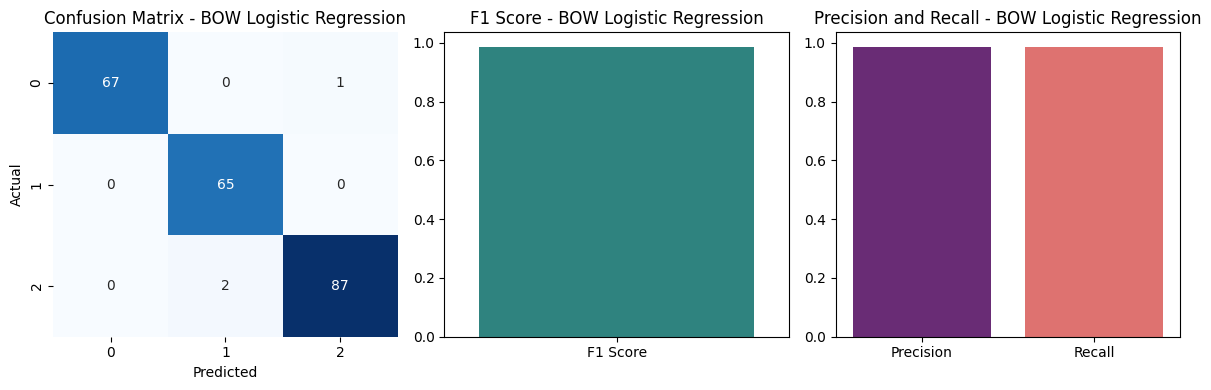

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Text_Work/Files/sentences.csv')
df1 = pd.read_csv('/content/drive/MyDrive/work2/Final/Text_Work/Files/updated_transcriptions_with_senti (1).csv')
urdu_doc = pd.concat([df, df1], ignore_index=True).dropna()

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Apply preprocessing
urdu_doc['text_cleaned'] = urdu_doc['Sentence'].map(removing_unwanted_data)

# Custom tokenizer function
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'

vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

# Transform the data using the loaded vectorizer
X = vectorizer.transform(urdu_doc['text_cleaned'])
y = urdu_doc['Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluate the loaded model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - BOW Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
plt.title("F1 Score - BOW Logistic Regression")

plt.subplot(1, 3, 3)
sns.barplot(x=['Precision', 'Recall'], y=[precision, recall], palette="magma")
plt.title("Precision and Recall - BOW Logistic Regression")

plt.tight_layout()
plt.show()

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['BOW Logistic Regression'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists and handle the append operation correctly
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    updated_df.to_csv(results_file, index=False)
else:
    results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head(10)


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.631285,0.636983,0.631285,0.630483
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final//Audio_Mode...,0.521739,0.557971,0.521739,0.445201
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201
4,BERT Multilingual,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.990991,0.991664,0.990792,0.991191
5,BOW Logistic Regression,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.986486,0.986704,0.986486,0.986500
6,BOW Logistic Regression,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.986486,0.986704,0.986486,0.986500


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 10 rows
print("Original DataFrame:")
print(results_df.head(10))

# Delete the last row
results_df = results_df[:-1]

# Save the updated DataFrame back to the CSV file
results_df.to_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv', index=False)

# Verify the last row has been deleted
print("Updated DataFrame:")
results_df.head(10)


Original DataFrame:
                Model Name                                         Model Path  \
0            Random Forest  /content/drive/MyDrive/work2/Final/Image_Model...   
1              MobileNetV2  /content/drive/MyDrive/work2/Final/Image_Model...   
2                     LSTM  /content/drive/MyDrive/work2/Final//Audio_Mode...   
3       Audio Sentiment RF  /content/drive/MyDrive/work2/Final/Audio_Model...   
4        BERT Multilingual  /content/drive/MyDrive/work2/Final/Text_Work/T...   
5  BOW Logistic Regression  /content/drive/MyDrive/work2/Final/Text_Work/T...   
6  BOW Logistic Regression  /content/drive/MyDrive/work2/Final/Text_Work/T...   

   Accuracy  Precision    Recall  F1 Score  
0  0.631285   0.636983  0.631285  0.630483  
1  0.653631   0.652923  0.653631  0.652066  
2  0.521739   0.557971  0.521739  0.445201  
3  0.521739   0.557971  0.521739  0.445201  
4  0.990991   0.991664  0.990792  0.991191  
5  0.986486   0.986704  0.986486  0.986500  
6  0.986486   0.

,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.631285,0.636983,0.631285,0.630483
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final//Audio_Mode...,0.521739,0.557971,0.521739,0.445201
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201
4,BERT Multilingual,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.990991,0.991664,0.990792,0.991191
5,BOW Logistic Regression,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.986486,0.986704,0.986486,0.986500


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head(10)

,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.631285,0.636983,0.631285,0.630483
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final//Audio_Mode...,0.521739,0.557971,0.521739,0.445201
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201
4,BERT Multilingual,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.990991,0.991664,0.990792,0.991191
5,BOW Logistic Regression,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.986486,0.986704,0.986486,0.986500
6,LSTM,/content/drive/MyDrive/work2/Final/Audio_Model...,0.529412,0.589154,0.529412,0.397359


In [ ]:

import pandas as pd
# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

results_df = results_df.drop(2)

# Save the updated DataFrame back to the CSV file
results_df.to_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv', index=False)

# Verify the second row has been deleted
print("Updated DataFrame:")
results_df.head(10)


Updated DataFrame:


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.631285,0.636983,0.631285,0.630483
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201
4,BERT Multilingual,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.990991,0.991664,0.990792,0.991191
5,BOW Logistic Regression,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.986486,0.986704,0.986486,0.986500
6,LSTM,/content/drive/MyDrive/work2/Final/Audio_Model...,0.529412,0.589154,0.529412,0.397359


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Swap the 4th and 6th rows (index 3 and 5 since it's zero-indexed)
results_df.iloc[[3, 5]] = results_df.iloc[[5, 3]].values

# Save the updated DataFrame back to the CSV file
results_df.to_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv', index=False)

# Verify the rows have been swapped
print("Updated DataFrame:")
results_df.head(10)




Updated DataFrame:


,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.631285,0.636983,0.631285,0.630483
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201
3,LSTM,/content/drive/MyDrive/work2/Final/Audio_Model...,0.529412,0.589154,0.529412,0.397359
4,BOW Logistic Regression,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.986486,0.986704,0.986486,0.986500
5,BERT Multilingual,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.990991,0.991664,0.990792,0.991191


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/evaluation_results.csv')

# Show the first 5 rows
results_df.head(10)

,Model Name,Model Path,Accuracy,Precision,Recall,F1 Score
0,Random Forest,/content/drive/MyDrive/work2/Final/Image_Model...,0.643123,0.644568,0.643123,0.643094
1,MobileNetV2,/content/drive/MyDrive/work2/Final/Image_Model...,0.653631,0.652923,0.653631,0.652066
2,LSTM,/content/drive/MyDrive/work2/Final/Old_audio_m...,0.529412,0.589154,0.529412,0.397359
3,Audio Sentiment RF,/content/drive/MyDrive/work2/Final/Audio_Model...,0.521739,0.557971,0.521739,0.445201
4,BERT Multilingual,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.990991,0.991160,0.990868,0.990921
5,BOW Logistic Regression,/content/drive/MyDrive/work2/Final/Text_Work/T...,0.986486,0.986704,0.986486,0.986500


#Table Creation for Sentiment Classfication based on 1 Video & its corresponding modalities (Audio,Text, Frame)

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Audio Model 1 (LSTM)

In [ ]:
import librosa
import numpy as np
import tensorflow as tf
import pandas as pd
import os

# Load the dataset
audio_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Audio.csv')

# Get the first audio file
first_audio_file = audio_df.iloc[1]['audio_name']

# Load the pre-trained model
audio_model_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5'
audio_model = tf.keras.models.load_model(audio_model_path)

# Helper function for audio feature extraction
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    energy_contour = librosa.feature.rms(y=y)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features = np.concatenate((
        np.mean(mfccs, axis=1),
        np.mean(mel, axis=1),
        np.mean(contrast, axis=1),
        np.mean(bandwidth, axis=1),
        np.mean(energy_contour, axis=1),
        np.mean(spectral_rolloff, axis=1)
    ))
    return features

# Predict audio sentiment
audio_path = f'/content/drive/MyDrive/work2_extra/wav/{first_audio_file}'
audio_features = extract_features(audio_path)
audio_features_scaled = np.expand_dims(audio_features, axis=0)
audio_features_scaled = np.expand_dims(audio_features_scaled, -1)
audio_pred = audio_model.predict(audio_features_scaled)[0]
audio_sentiment = np.argmax(audio_pred)
audio_percentage = audio_pred[audio_sentiment]

# Save results to a DataFrame
results_df_audio1 = pd.DataFrame({
    'Modality': ['Audio Model 1'],
    'Sentiment': ['neutral' if audio_sentiment == 0 else 'positive' if audio_sentiment == 1 else 'negative'],
    'Percentage': [audio_percentage]
})

# Save to CSV for combining later
results_df_audio1.to_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1.csv', index=False)
print("Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1.csv")


1/1 [==============================] - 1s 1s/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1.csv


#Audio Model 2 (Random Forest)

In [ ]:
import librosa
import numpy as np
import pandas as pd
import joblib
import os

# Load the dataset
audio_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Audio.csv')

# Get the first audio file
first_audio_file = audio_df.iloc[1]['audio_name']

# Load the pre-trained model
audio_model_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest.joblib'
audio_scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest_Scaler.joblib'
audio_model = joblib.load(audio_model_path)
audio_scaler = joblib.load(audio_scaler_path)

# Helper function for audio feature extraction
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)
    spectral_contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr), axis=1)
    features = np.concatenate((mfccs, chroma, mel, spectral_contrast, tonnetz))
    return features

# Predict audio sentiment
audio_path = f'/content/drive/MyDrive/work2_extra/wav/{first_audio_file}'
audio_features = extract_features(audio_path)
audio_features_scaled = audio_scaler.transform([audio_features])
audio_pred = audio_model.predict_proba(audio_features_scaled)[0]
audio_sentiment = np.argmax(audio_pred)
audio_percentage = audio_pred[audio_sentiment]

# Save results to a DataFrame
results_df_audio2 = pd.DataFrame({
    'Modality': ['Audio Model 2'],
    'Sentiment': ['neutral' if audio_sentiment == 0 else 'positive' if audio_sentiment == 1 else 'negative'],
    'Percentage': [audio_percentage]
})

# Save to CSV for combining later
results_df_audio2.to_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2.csv', index=False)
print("Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2.csv")


Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2.csv


#Text Model 1 (BERT)

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, SequentialSampler, TensorDataset
import numpy as np
import pandas as pd

# Load the dataset
text_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Text.csv')

# Get the first text transcription
first_text = text_df.iloc[1]['Transcript']

# Load the pre-trained model and tokenizer
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')
model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

# Tokenize and encode the text
encoded_dict = tokenizer.encode_plus(
    first_text,
    add_special_tokens=True,
    max_length=64,
    truncation=True,
    padding='max_length',
    return_attention_mask=True,
    return_tensors='pt'
)

input_ids = encoded_dict['input_ids']
attention_mask = encoded_dict['attention_mask']

# Create DataLoader
dataset = TensorDataset(input_ids, attention_mask)
dataloader = DataLoader(dataset, sampler=SequentialSampler(dataset), batch_size=1)

# Predict text sentiment
model.eval()
with torch.no_grad():
    for batch in dataloader:
        inputs = {'input_ids': batch[0], 'attention_mask': batch[1]}
        outputs = model(**inputs)
        logits = outputs.logits
        preds = torch.softmax(logits, dim=1).cpu().numpy()

text_sentiment = np.argmax(preds)
text_percentage = preds[0][text_sentiment]

# Save results to a DataFrame
results_df_text1 = pd.DataFrame({
    'Modality': ['Text Model 1'],
    'Sentiment': ['neutral' if text_sentiment == 0 else 'positive' if text_sentiment == 1 else 'negative'],
    'Percentage': [text_percentage]
})

# Save to CSV for combining later
results_df_text1.to_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1.csv', index=False)
print("Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1.csv")


Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1.csv


#Text Model 2 (Logistic Regression)

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib

# Load the dataset
text_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Text.csv')

# Get the first text transcription
first_text = text_df.iloc[1]['Transcript']

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', ' ', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Apply preprocessing
cleaned_text = removing_unwanted_data(first_text)

# Redefine custom tokenizer function
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'
vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

# Transform the data using the loaded vectorizer
X = vectorizer.transform([' '.join(cleaned_text)])

# Predict text sentiment
text_pred = model.predict_proba(X)[0]
text_sentiment = np.argmax(text_pred)
text_percentage = text_pred[text_sentiment]

# Save results to a DataFrame
results_df_text2 = pd.DataFrame({
    'Modality': ['Text Model 2'],
    'Sentiment': ['neutral' if text_sentiment == 0 else 'positive' if text_sentiment == 1 else 'negative'],
    'Percentage': [text_percentage]
})

# Save to CSV for combining later
results_df_text2.to_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2.csv', index=False)
print("Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2.csv")


Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2.csv


##Video Model 1 (MobileNetV2)

In [ ]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import os

# Load the datasets
frames_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Frames_Meta_Data.csv')
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Get the first video name
first_video_name = videos_df.iloc[1]['File'].replace('.mp4', '')

# Get the frames corresponding to the first video and key frames only
first_video_frames = frames_df[(frames_df['Video Name'].astype(str) == first_video_name) & (frames_df['Key_Frame'] == 'Y')]

# Load the pre-trained model
video_model_path = '/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_1_CNN_with_MobileNetV2.h5'
video_model = tf.keras.models.load_model(video_model_path)

# Helper function for video feature extraction
def preprocess_image(filepath):
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = preprocess_input(img)
    return img

# Predict video sentiment
predictions = []
for frame_path in first_video_frames['Frame Path']:
    video_image = preprocess_image(frame_path)
    if video_image is not None:
        video_image = np.expand_dims(video_image, axis=0)
        video_pred = video_model.predict(video_image)[0]
        predictions.append(video_pred)

if predictions:
    # Average predictions
    average_pred = np.mean(predictions, axis=0)
    video_sentiment = np.argmax(average_pred)
    video_percentage = average_pred[video_sentiment]

    # Save results to a DataFrame
    results_df_video1 = pd.DataFrame({
        'Modality': ['Video Model 1'],
        'Sentiment': ['neutral' if video_sentiment == 0 else 'positive' if video_sentiment == 1 else 'negative'],
        'Percentage': [video_percentage]
    })

    # Save to CSV for combining later
    results_df_video1.to_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1.csv', index=False)
    print("Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video1.csv")
else:
    print("No valid frames were processed.")


1/1 [==============================] - 0s 89ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video1.csv


In [ ]:
 results_df_video1.head()


,Modality,Sentiment,Percentage
0,Video Model 1,neutral,0.869704


#Video Model 2 (Video_Model_2_random_forest_model)

In [ ]:
import numpy as np
import pandas as pd
import cv2
import joblib
from skimage.feature import hog

# Load the datasets
frames_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Frames_Meta_Data.csv')
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Get the first video name
first_video_name = videos_df.iloc[1]['File'].replace('.mp4', '')

# Get the frames corresponding to the first video and key frames only
first_video_frames = frames_df[(frames_df['Video Name'].astype(str) == first_video_name) & (frames_df['Key_Frame'] == 'Y')]

# Load the pre-trained model
video_model_path = '/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl'
video_model = joblib.load(video_model_path)

# Helper function for video feature extraction
def preprocess_image(filepath):
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128, 128))
    hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')
    return hog_features

# Predict video sentiment
predictions = []
for frame_path in first_video_frames['Frame Path']:
    video_features = preprocess_image(frame_path)
    if video_features is not None:
        video_features = video_features.reshape(1, -1)
        video_pred = video_model.predict_proba(video_features)[0]
        predictions.append(video_pred)

if predictions:
    # Average predictions
    average_pred = np.mean(predictions, axis=0)
    video_sentiment = np.argmax(average_pred)
    video_percentage = average_pred[video_sentiment]

    # Save results to a DataFrame
    results_df_video2 = pd.DataFrame({
        'Modality': ['Video Model 2'],
        'Sentiment': ['neutral' if video_sentiment == 0 else 'positive' if video_sentiment == 1 else 'negative'],
        'Percentage': [video_percentage]
    })

    # Save to CSV for combining later
    results_df_video2.to_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2.csv', index=False)
    print("Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2.csv")
else:
    print("No valid frames were processed.")


Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2.csv


#Model Essembling

In [ ]:
import os
import pandas as pd

# Load individual model results
results_audio1 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1.csv')
results_audio2 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2.csv')
results_text1 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1.csv')
results_text2 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2.csv')
results_video1 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1.csv')
results_video2 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2.csv')

# Load the videos dataset to get the actual sentiment
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Combine all results into a single DataFrame
ensemble_results = pd.concat([results_audio1, results_audio2, results_text1, results_text2, results_video1, results_video2], ignore_index=True)

# Print the combined results for verification
print("Combined Model Results:")
print(ensemble_results)

# Calculate the final sentiment based on weighted averages
# You can adjust the weights as needed
weights = {
    'Audio Model 1': 0.529,
    'Audio Model 2': 0.521,
    'Text Model 1': 0.990,
    'Text Model 2': 0.986,
    'Video Model 1': 0.643,
    'Video Model 2': 0.653
}

# Apply weights to the percentages
ensemble_results['Weighted Percentage'] = ensemble_results.apply(lambda row: row['Percentage'] * weights[row['Modality']], axis=1)

# Determine the maximum predicted sentiment among all six modalities
max_predicted_sentiment = ensemble_results.loc[ensemble_results['Percentage'].idxmax()]

# Update weights with an additional parameter for the maximum predicted sentiment
max_weight = 0.33  # Adjust this weight as needed
ensemble_results['Weighted Percentage'] = ensemble_results.apply(
    lambda row: row['Weighted Percentage'] + (max_weight * max_predicted_sentiment['Percentage']) if row['Sentiment'] == max_predicted_sentiment['Sentiment'] else row['Weighted Percentage'],
    axis=1
)

# Determine the final sentiment by selecting the sentiment with the highest weighted percentage
final_sentiment = ensemble_results.loc[ensemble_results['Weighted Percentage'].idxmax()]

# Get the actual sentiment for the first video
first_video_name = '2.mp4'  # Update with the appropriate video file name if needed
actual_senti = videos_df[videos_df['File'] == first_video_name]['Senti'].values[0]

# Print the final sentiment
print("\nFinal Ensemble Sentiment Result:")
print(final_sentiment)

# Capture dynamic values for 'Modality' and 'Percentage'
modality = final_sentiment['Modality']
percentage = final_sentiment['Percentage']

# Save the final result to a CSV file
final_result_df = pd.DataFrame({
    'File': [first_video_name],
    'Actual Senti': [actual_senti],
    'Predicted Sentiment': [final_sentiment['Sentiment']],
    'Weighted Percentage': [final_sentiment['Weighted Percentage']],
    'Modality': [modality],       # Dynamically captured modality
    'Percentage': [percentage]    # Dynamically captured percentage
})

# Define the path to the CSV file
csv_file_path = '/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result.csv'

# Check if the file exists and save accordingly
if not os.path.exists(csv_file_path):
    # If the file does not exist, create it with the header
    final_result_df.to_csv(csv_file_path, index=False)
else:
    # If the file exists, append without the header
    final_result_df.to_csv(csv_file_path, mode='a', header=False, index=False)

print(f"Final ensemble result saved to {csv_file_path}")


Combined Model Results:
        Modality Sentiment  Percentage
0  Audio Model 1  negative    0.413837
1  Audio Model 2  positive    0.520000
2   Text Model 1  positive    0.987904
3   Text Model 2  negative    0.600162
4  Video Model 1  positive    0.571877
5  Video Model 2   neutral    0.402372

Final Ensemble Sentiment Result:
Modality               Text Model 1
Sentiment                  positive
Percentage                 0.987904
Weighted Percentage        1.304033
Name: 2, dtype: object
Final ensemble result saved to /content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result.csv


In [ ]:
import pandas as pd

# Read the CSV file
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result.csv')

# Show the first 5 rows
results_df.head()


,File,Actual Senti,Predicted Sentiment,Weighted Percentage,Modality,Percentage
0,2.mp4,0,positive,1.304033,Text Model 1,0.987904


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

# Load your evaluation metrics DataFrame
results_df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result.csv')

# Drop the third row (index 1)
results_df.drop([0], axis=0, inplace=True)

# Save the modified DataFrame back to the CSV file
results_df.to_csv('/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result.csv', index=False)

print("Record at row 1 has been deleted and the file has been saved.")

#results_df.drop([1, 2], axis=0, inplace=True)
#results_df.to_csv('/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result.csv', index=False)


Record at row 1 has been deleted and the file has been saved.


In [ ]:
print("Test")

In [ ]:
import os
import pandas as pd

# Load individual model results
results_audio1 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1.csv')
results_audio2 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2.csv')
results_text1 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1.csv')
results_text2 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2.csv')
results_video1 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1.csv')
results_video2 = pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2.csv')

# Load the videos dataset to get the actual sentiment
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Define weights for each model
weights = {
    'Audio Model 1': 0.529,
    'Audio Model 2': 0.521,
    'Text Model 1': 0.990,
    'Text Model 2': 0.986,
    'Video Model 1': 0.643,
    'Video Model 2': 0.653
}

# Phase 1: Fusion within each modality
def fuse_modality_pair(model1, model2, weight1, weight2):
    combined = pd.concat([model1, model2], ignore_index=True)
    combined['Weighted Percentage'] = combined.apply(lambda row: row['Percentage'] * (weight1 if row['Modality'] == model1['Modality'].iloc[0] else weight2), axis=1)
    return combined.loc[combined['Weighted Percentage'].idxmax()]

audio_result = fuse_modality_pair(results_audio1, results_audio2, weights['Audio Model 1'], weights['Audio Model 2'])
text_result = fuse_modality_pair(results_text1, results_text2, weights['Text Model 1'], weights['Text Model 2'])
video_result = fuse_modality_pair(results_video1, results_video2, weights['Video Model 1'], weights['Video Model 2'])

# Combine results from all modalities
phase1_results = pd.DataFrame([audio_result, text_result, video_result])

print("Phase 1 Results (Fusion within each modality):")
print(phase1_results[['Modality', 'Sentiment', 'Percentage', 'Weighted Percentage']])

# Phase 2: Fusion across modalities
max_predicted_sentiment = phase1_results.loc[phase1_results['Percentage'].idxmax()]
max_sentiment = max_predicted_sentiment['Sentiment']
max_percentage = max_predicted_sentiment['Percentage']
max_weight = 0.33  # Adjust this weight as needed

# Calculate Final Weighted Percentage
phase1_results['Final Weighted Percentage'] = phase1_results.apply(
    lambda row: row['Weighted Percentage'] + (max_weight * max_percentage if str(row['Sentiment']) == str(max_sentiment) else 0),
    axis=1
)

# Determine the final sentiment
final_sentiment = phase1_results.loc[phase1_results['Final Weighted Percentage'].idxmax()]

# Get the actual sentiment for the first video
first_video_name = '2.mp4'  # Update with the appropriate video file name if needed
actual_senti = videos_df[videos_df['File'] == first_video_name]['Senti'].values[0]

print("\nFinal Ensemble Sentiment Result:")
print(final_sentiment)

# Save the final result to a CSV file
final_result_df = pd.DataFrame({
    'File': [first_video_name],
    'Actual Senti': [actual_senti],
    'Predicted Sentiment': [final_sentiment['Sentiment']],
    'Weighted Percentage': [final_sentiment['Final Weighted Percentage']],
    'Modality': [final_sentiment['Modality']],
    'Percentage': [final_sentiment['Percentage']]
})

# Define the path to the CSV file
csv_file_path = '/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result2.csv'

# Check if the file exists and save accordingly
if not os.path.exists(csv_file_path):
    final_result_df.to_csv(csv_file_path, index=False)
else:
    final_result_df.to_csv(csv_file_path, mode='a', header=False, index=False)

print(f"Final ensemble result saved to {csv_file_path}")


Phase 1 Results (Fusion within each modality):
        Modality Sentiment  Percentage  Weighted Percentage
1  Audio Model 2  positive    0.520000             0.270920
0   Text Model 1  positive    0.987904             0.978025
0  Video Model 1  positive    0.571877             0.367717

Final Ensemble Sentiment Result:
        Modality Sentiment  Percentage  Weighted Percentage  \
0   Text Model 1  positive    0.987904             0.978025   
0  Video Model 1  positive    0.571877             0.367717   

   Final Weighted Percentage  
0                   0.978025  
0                   0.367717  
Final ensemble result saved to /content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result2.csv


# **Table Creation for Sentiment Classfication based on First 2 Videos & its corresponding modalities (Audio,Text, Frame)**

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Audio Model 1 (First 2 Files Results)

In [ ]:
import librosa
import numpy as np
import tensorflow as tf
import pandas as pd
import os

# Load the dataset
audio_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Audio.csv')

# Load the pre-trained model
audio_model_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5'
audio_model = tf.keras.models.load_model(audio_model_path)

# Helper function for audio feature extraction
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    energy_contour = librosa.feature.rms(y=y)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features = np.concatenate((
        np.mean(mfccs, axis=1),
        np.mean(mel, axis=1),
        np.mean(contrast, axis=1),
        np.mean(bandwidth, axis=1),
        np.mean(energy_contour, axis=1),
        np.mean(spectral_rolloff, axis=1)
    ))
    return features

# Function to predict audio sentiment
def predict_audio_sentiment(audio_file):
    audio_path = f'/content/drive/MyDrive/work2_extra/wav/{audio_file}'
    audio_features = extract_features(audio_path)
    audio_features_scaled = np.expand_dims(audio_features, axis=0)
    audio_features_scaled = np.expand_dims(audio_features_scaled, -1)
    audio_pred = audio_model.predict(audio_features_scaled)[0]
    audio_sentiment = np.argmax(audio_pred)
    audio_percentage = audio_pred[audio_sentiment]

    sentiment_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

    return {
        'Modality': 'Audio Model 1',
        'Sentiment': sentiment_map[audio_sentiment],
        'Percentage': audio_percentage
    }

# Process the first two audio files
for i in range(111):
    audio_file = audio_df.iloc[i]['audio_name']
    result = predict_audio_sentiment(audio_file)

    # Save individual result to CSV
    results_df = pd.DataFrame([result])
    output_path = f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_{i+1}.csv'
    results_df.to_csv(output_path, index=False)
    print(f"Results saved to {output_path}")

1/1 [==============================] - 2s 2s/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_1.csv
1/1 [==============================] - 0s 99ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_2.csv
1/1 [==============================] - 0s 177ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_3.csv
1/1 [==============================] - 0s 186ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_4.csv
1/1 [==============================] - 0s 189ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_5.csv
1/1 [==============================] - 0s 151ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_6.csv
1/1 [==============================] - 0s 240ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_7.csv
1/1 [============

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_1.csv')
df.head()

,Modality,Sentiment,Percentage
0,Audio Model 1,negative,0.417261


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_2.csv')
df.head()

,Modality,Sentiment,Percentage
0,Audio Model 1,negative,0.413837


## Audio Model 2 (First 2 Files Results)

In [ ]:
import librosa
import numpy as np
import pandas as pd
import joblib
import os

# Load the dataset
audio_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Audio.csv')

# Load the pre-trained model and scaler
audio_model_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest.joblib'
audio_scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest_Scaler.joblib'
audio_model = joblib.load(audio_model_path)
audio_scaler = joblib.load(audio_scaler_path)

# Helper function for audio feature extraction
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)
    spectral_contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr), axis=1)
    features = np.concatenate((mfccs, chroma, mel, spectral_contrast, tonnetz))
    return features

# Function to predict audio sentiment
def predict_audio_sentiment(audio_file):
    audio_path = f'/content/drive/MyDrive/work2_extra/wav/{audio_file}'
    audio_features = extract_features(audio_path)
    audio_features_scaled = audio_scaler.transform([audio_features])
    audio_pred = audio_model.predict_proba(audio_features_scaled)[0]
    audio_sentiment = np.argmax(audio_pred)
    audio_percentage = audio_pred[audio_sentiment]

    sentiment_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

    return {
        'Modality': 'Audio Model 2',
        'Sentiment': sentiment_map[audio_sentiment],
        'Percentage': audio_percentage
    }

# Process the first two audio files
for i in range(111):
    audio_file = audio_df.iloc[i]['audio_name']
    result = predict_audio_sentiment(audio_file)

    # Save individual result to CSV
    results_df = pd.DataFrame([result])
    output_path = f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_{i+1}.csv'
    results_df.to_csv(output_path, index=False)
    print(f"Results saved to {output_path}")

Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_1.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_2.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_3.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_4.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_5.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_6.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_7.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_8.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_9.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_10.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_11.csv
Results saved to /content/driv

## Text Model 1 (BERT) (First 2 Files Results)

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, SequentialSampler, TensorDataset
import numpy as np
import pandas as pd

# Load the dataset
text_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Text.csv')

# Load the pre-trained model and tokenizer
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')
model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

def predict_text_sentiment(text):
    # Tokenize and encode the text
    encoded_dict = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoded_dict['input_ids']
    attention_mask = encoded_dict['attention_mask']

    # Create DataLoader
    dataset = TensorDataset(input_ids, attention_mask)
    dataloader = DataLoader(dataset, sampler=SequentialSampler(dataset), batch_size=1)

    # Predict text sentiment
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            inputs = {'input_ids': batch[0], 'attention_mask': batch[1]}
            outputs = model(**inputs)
            logits = outputs.logits
            preds = torch.softmax(logits, dim=1).cpu().numpy()

    text_sentiment = np.argmax(preds)
    text_percentage = preds[0][text_sentiment]

    sentiment_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

    return {
        'Modality': 'Text Model 1',
        'Sentiment': sentiment_map[text_sentiment],
        'Percentage': text_percentage
    }

# Process the first two text transcriptions
for i in range(111):
    text = text_df.iloc[i]['Transcript']
    result = predict_text_sentiment(text)

    # Save individual result to CSV
    results_df = pd.DataFrame([result])
    output_path = f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_{i+1}.csv'
    results_df.to_csv(output_path, index=False)
    print(f"Results saved to {output_path}")

Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_1.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_2.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_3.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_4.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_5.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_6.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_7.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_8.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_9.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_10.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_11.csv
Results saved to /content/drive/MyDrive/w

## Text Model 2 (Logistic Regression) (First 2 Files Results)

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib

# Load the dataset
text_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Text.csv')

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', ' ', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Redefine custom tokenizer function
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'
vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

def predict_text_sentiment(text):
    # Apply preprocessing
    cleaned_text = removing_unwanted_data(text)

    # Transform the data using the loaded vectorizer
    X = vectorizer.transform([' '.join(cleaned_text)])

    # Predict text sentiment
    text_pred = model.predict_proba(X)[0]
    text_sentiment = np.argmax(text_pred)
    text_percentage = text_pred[text_sentiment]

    sentiment_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

    return {
        'Modality': 'Text Model 2',
        'Sentiment': sentiment_map[text_sentiment],
        'Percentage': text_percentage
    }

# Process the first two text transcriptions
for i in range(111):
    text = text_df.iloc[i]['Transcript']
    result = predict_text_sentiment(text)

    # Save individual result to CSV
    results_df = pd.DataFrame([result])
    output_path = f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_{i+1}.csv'
    results_df.to_csv(output_path, index=False)
    print(f"Results saved to {output_path}")

Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_1.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_2.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_3.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_4.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_5.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_6.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_7.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_8.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_9.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_10.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_11.csv
Results saved to /content/drive/MyDrive/w

## Video Model 1 (MobileNetV2) (First 2 Files Results)

In [ ]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import os

# Load the datasets
frames_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Frames_Meta_Data.csv')
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Load the pre-trained model
video_model_path = '/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_1_CNN_with_MobileNetV2.h5'
video_model = tf.keras.models.load_model(video_model_path)

# Helper function for video feature extraction
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File does not exist: {filepath}")
        return None

    try:
        img = cv2.imread(filepath)
        if img is None:
            print(f"Failed to read image: {filepath}")
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = preprocess_input(img)
        return img
    except Exception as e:
        print(f"Error processing image {filepath}: {str(e)}")
        return None

def predict_video_sentiment(video_name):
    # Get the frames corresponding to the video and key frames only
    video_frames = frames_df[(frames_df['Video Name'].astype(str) == video_name) & (frames_df['Key_Frame'] == 'Y')]

    predictions = []
    for _, row in video_frames.iterrows():
        frame_path = row['Frame Path']
        video_image = preprocess_image(frame_path)
        if video_image is not None:
            video_image = np.expand_dims(video_image, axis=0)
            video_pred = video_model.predict(video_image)[0]
            predictions.append(video_pred)

    if predictions:
        # Average predictions
        average_pred = np.mean(predictions, axis=0)
        video_sentiment = np.argmax(average_pred)
        video_percentage = average_pred[video_sentiment]

        sentiment_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

        return {
            'Modality': 'Video Model 1',
            'Sentiment': sentiment_map[video_sentiment],
            'Percentage': video_percentage
        }
    else:
        print(f"No valid frames were processed for video: {video_name}")
        return None

# Process the first two videos
for i in range(111):
    video_name = videos_df.iloc[i]['File'].replace('.mp4', '')
    print(f"Processing video: {video_name}")

    # Print some debug information
    video_frames = frames_df[(frames_df['Video Name'].astype(str) == video_name) & (frames_df['Key_Frame'] == 'Y')]
    print(f"Number of key frames for video {video_name}: {len(video_frames)}")
    print("First few frame paths:")
    print(video_frames['Frame Path'].head())

    result = predict_video_sentiment(video_name)

    if result:
        # Save individual result to CSV
        results_df = pd.DataFrame([result])
        output_path = f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1_{i+1}.csv'
        results_df.to_csv(output_path, index=False)
        print(f"Results saved to {output_path}")
    else:
        print(f"Failed to process video: {video_name}")

# Print the first few rows of the frames_df to verify the data
print("\nFirst few rows of frames_df:")
print(frames_df.head())

# Print the first few rows of the videos_df to verify the data
print("\nFirst few rows of videos_df:")
print(videos_df.head())

Processing video: 1
Number of key frames for video 1: 19
First few frame paths:
323    /content/drive/MyDrive/work2/Frames/1/1_frame_...
324    /content/drive/MyDrive/work2/Frames/1/1_frame_...
325    /content/drive/MyDrive/work2/Frames/1/1_frame_...
326    /content/drive/MyDrive/work2/Frames/1/1_frame_...
327    /content/drive/MyDrive/work2/Frames/1/1_frame_...
Name: Frame Path, dtype: object
1/1 [==============================] - 0s 74ms/step
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video1_1.csv
Processing video: 2
Number of key frames for video 2: 22
First few frame paths:
117    /content/drive/MyDrive/work2/Frames/2/2_frame_...
118    /content/drive/MyDrive/work2/Frames/2/2_frame_...
119    /content/drive/MyDrive/work2/Frames/2/2_frame_...
120    /content/drive/MyDrive/work2/Frames/2/2_frame_...
121    /content/drive/MyDrive/work2/Frames/2/2_frame_...
Name: Frame Path, dtype: object
1/1 [==============================] - 0s 61ms/step
Results saved 

## Video Model 2 (Video_Model_2_random_forest_model) (First 2 Files Results)

In [ ]:
import numpy as np
import pandas as pd
import cv2
import joblib
from skimage.feature import hog

# Load the datasets
frames_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Frames_Meta_Data.csv')
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Load the pre-trained model
video_model_path = '/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl'
video_model = joblib.load(video_model_path)

# Helper function for video feature extraction
def preprocess_image(filepath):
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128, 128))
    hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')
    return hog_features

def predict_video_sentiment(video_name):
    # Get the frames corresponding to the video and key frames only
    video_frames = frames_df[(frames_df['Video Name'].astype(str) == video_name) & (frames_df['Key_Frame'] == 'Y')]

    predictions = []
    for frame_path in video_frames['Frame Path']:
        video_features = preprocess_image(frame_path)
        if video_features is not None:
            video_features = video_features.reshape(1, -1)
            video_pred = video_model.predict_proba(video_features)[0]
            predictions.append(video_pred)

    if predictions:
        # Average predictions
        average_pred = np.mean(predictions, axis=0)
        video_sentiment = np.argmax(average_pred)
        video_percentage = average_pred[video_sentiment]

        sentiment_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

        return {
            'Modality': 'Video Model 2',
            'Sentiment': sentiment_map[video_sentiment],
            'Percentage': video_percentage
        }
    else:
        print(f"No valid frames were processed for video: {video_name}")
        return None

# Process the first two videos
for i in range(111):
    video_name = videos_df.iloc[i]['File'].replace('.mp4', '')
    result = predict_video_sentiment(video_name)

    if result:
        # Save individual result to CSV
        results_df = pd.DataFrame([result])
        output_path = f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_{i+1}.csv'
        results_df.to_csv(output_path, index=False)
        print(f"Results saved to {output_path}")
    else:
        print(f"Failed to process video: {video_name}")

Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_1.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_2.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_3.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_4.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_5.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_6.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_7.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_8.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_9.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_10.csv
Results saved to /content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_11.csv
Results saved to /content/driv

*   The actual sentiment (from the original dataset)
*   The predicted sentiment (from your ensemble model)
*   The weighted percentage (confidence of the prediction)
*   The modality that contributed most to the final prediction
*   The percentage (confidence) of that modality

In [ ]:
import pandas as pd

def display_final_results():
    csv_file_path = '/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result2.csv'

    try:
        results_df = pd.read_csv(csv_file_path)

        # Remove '\n' characters from all string columns
        for column in results_df.columns:
            if results_df[column].dtype == 'object':
                results_df[column] = results_df[column].str.replace('\n', ' ')

        print("Final Ensemble Results:")
        print(results_df.to_string(index=False))
    except FileNotFoundError:
        print(f"Error: The file {csv_file_path} was not found.")
    except pd.errors.EmptyDataError:
        print(f"Error: The file {csv_file_path} is empty.")
    except Exception as e:
        print(f"An error occurred while reading the file: {str(e)}")

# Call the function to display the results
display_final_results()

Final Ensemble Results:
   File  Actual Senti                                                      Predicted Sentiment                                                                       Weighted Percentage                                                                               Modality                                                                 Percentage
  2.mp4             0               0    positive 0    positive Name: Sentiment, dtype: object               0    0.978025 0    0.367717 Name: Final Weighted Percentage, dtype: float64                    0     Text Model 1 0    Video Model 1 Name: Modality, dtype: object               0    0.987904 0    0.571877 Name: Percentage, dtype: float64
  2.mp4             0               0    positive 0    positive Name: Sentiment, dtype: object               0    0.978025 0    0.367717 Name: Final Weighted Percentage, dtype: float64                    0     Text Model 1 0    Video Model 1 Name: Modality, dtype: object           

#@@@ For All Videos


In [ ]:
import os
import pandas as pd

# Load the videos dataset to get the actual sentiment
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Define weights for each model
weights = {
    'Audio Model 1': 0.529,
    'Audio Model 2': 0.521,
    'Text Model 1': 0.990,
    'Text Model 2': 0.986,
    'Video Model 1': 0.643,
    'Video Model 2': 0.653
}

# Function to process each video
def process_file(file_number, video_name):
    # Load results from all models for the given file_number
    results_audio1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_{file_number}.csv')
    results_audio2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_{file_number}.csv')
    results_text1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_{file_number}.csv')
    results_text2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_{file_number}.csv')
    results_video1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1_{file_number}.csv')
    results_video2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_{file_number}.csv')

    # Combine all results into a single DataFrame
    ensemble_results = pd.concat([results_audio1, results_audio2, results_text1, results_text2, results_video1, results_video2], ignore_index=True)

    # Apply weights to the percentages
    ensemble_results['Weighted Percentage'] = ensemble_results.apply(lambda row: row['Percentage'] * weights[row['Modality']], axis=1)

    # Determine the maximum predicted sentiment among all six modalities
    max_predicted_sentiment = ensemble_results.loc[ensemble_results['Percentage'].idxmax()]

    # Update weights with an additional parameter for the maximum predicted sentiment
    max_weight = 0.33  # Adjust this weight as needed
    ensemble_results['Weighted Percentage'] = ensemble_results.apply(
        lambda row: row['Weighted Percentage'] + (max_weight * max_predicted_sentiment['Percentage']) if row['Sentiment'] == max_predicted_sentiment['Sentiment'] else row['Weighted Percentage'],
        axis=1
    )

    # Determine the final sentiment by selecting the sentiment with the highest weighted percentage
    final_sentiment = ensemble_results.loc[ensemble_results['Weighted Percentage'].idxmax()]

    # Get the actual sentiment for the video from the videos_df
    actual_senti = videos_df[videos_df['File'] == video_name]['Senti'].values[0]

    # Capture dynamic values for 'Modality' and 'Percentage'
    modality = final_sentiment['Modality']
    percentage = final_sentiment['Percentage']

    # Return the results
    return {
        'File': video_name,
        'Actual Senti': actual_senti,
        'Predicted Sentiment': final_sentiment['Sentiment'],
        'Weighted Percentage': final_sentiment['Weighted Percentage'],
        'Modality': modality,       # Dynamically captured modality
        'Percentage': percentage    # Dynamically captured percentage
    }

# Create an empty list to store results
final_results = []

# Loop through all the videos in the Meta_Data
for index, row in videos_df.iterrows():
    video_name = row['File']
    file_number = index + 1  # Assuming the file number corresponds to the row index + 1

    # Process each file and append the results
    result = process_file(file_number, video_name)
    final_results.append(result)

# Convert the results to a DataFrame
final_result_df = pd.DataFrame(final_results)

# Define the path to the CSV file
csv_file_path = '/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result_All_Videos.csv'

# Check if the file exists and save accordingly
if not os.path.exists(csv_file_path):
    # If the file does not exist, create it with the header
    final_result_df.to_csv(csv_file_path, index=False)
else:
    # If the file exists, append without the header
    final_result_df.to_csv(csv_file_path, mode='a', header=False, index=False)

print(f"Final ensemble result saved to {csv_file_path}")


Final ensemble result saved to /content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result_All_Videos.csv


In [ ]:
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result_All_Videos.csv')

# Display the first 5 instances
df.head(125)


,File,Actual Senti,Predicted Sentiment,Weighted Percentage,Modality,Percentage
0,1.mp4,2,negative,1.098870,Text Model 2,0.835007
1,2.mp4,1,positive,1.304033,Text Model 1,0.987904
2,3.mp4,2,negative,1.315969,Text Model 2,0.999976
3,4.mp4,2,negative,1.315555,Text Model 2,0.999662
4,5.mp4,2,negative,1.315912,Text Model 2,0.999933
...,...,...,...,...,...,...
106,107.mp4,0,negative,1.291415,Text Model 2,0.981319
107,108.mp4,0,negative,1.311833,Text Model 2,0.996833
108,109.mp4,2,negative,1.315916,Text Model 2,0.999936
109,110.mp4,2,negative,1.313410,Text Model 2,0.998032


In [ ]:
import os
import pandas as pd

# Load the videos dataset to get the actual sentiment
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Define weights for each model
weights = {
    'Audio Model 1': 0.529,
    'Audio Model 2': 0.521,
    'Text Model 1': 0.990,
    'Text Model 2': 0.986,
    'Video Model 1': 0.643,
    'Video Model 2': 0.653
}

# Function to process each video
def process_file(file_number, video_name):
    # Load results from all models for the given file_number
    results_audio1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_{file_number}.csv')
    results_audio2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_{file_number}.csv')
    results_text1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_{file_number}.csv')
    results_text2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_{file_number}.csv')
    results_video1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1_{file_number}.csv')
    results_video2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_{file_number}.csv')

    # Combine all results into a single DataFrame
    ensemble_results = pd.concat([results_audio1, results_audio2, results_text1, results_text2, results_video1, results_video2], ignore_index=True)

    # Apply weights to the percentages
    ensemble_results['Weighted Percentage'] = ensemble_results.apply(lambda row: row['Percentage'] * weights[row['Modality']], axis=1)

    # Determine the maximum predicted sentiment among all six modalities
    max_predicted_sentiment = ensemble_results.loc[ensemble_results['Percentage'].idxmax()]

    # Update weights with an additional parameter for the maximum predicted sentiment
    max_weight = 0.33  # Adjust this weight as needed
    ensemble_results['Weighted Percentage'] = ensemble_results.apply(
        lambda row: row['Weighted Percentage'] + (max_weight * max_predicted_sentiment['Percentage']) if row['Sentiment'] == max_predicted_sentiment['Sentiment'] else row['Weighted Percentage'],
        axis=1
    )

    # Determine the final sentiment by selecting the sentiment with the highest weighted percentage
    final_sentiment = ensemble_results.loc[ensemble_results['Weighted Percentage'].idxmax()]

    # Get the actual sentiment for the video from the videos_df
    actual_senti = videos_df[videos_df['File'] == video_name]['Senti'].values[0]

    # Capture dynamic values for 'Modality' and 'Percentage'
    modality = final_sentiment['Modality']
    percentage = final_sentiment['Percentage']

    # Return the results
    return {
        'File': video_name,
        'Actual Senti': actual_senti,
        'Predicted Sentiment': final_sentiment['Sentiment'],
        'Weighted Percentage': final_sentiment['Weighted Percentage'],
        'Modality': modality,       # Dynamically captured modality
        'Percentage': percentage    # Dynamically captured percentage
    }

# Create an empty list to store results
final_results = []

# Loop through all the videos in the Meta_Data
for index, row in videos_df.iterrows():
    video_name = row['File']
    file_number = index + 1  # Assuming the file number corresponds to the row index + 1

    # Process each file and append the results
    result = process_file(file_number, video_name)
    final_results.append(result)

# Convert the results to a DataFrame
final_result_df = pd.DataFrame(final_results)

# Define the path to the CSV file
csv_file_path = '/content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result_All_Videos2.csv'

# Check if the file exists and save accordingly
if not os.path.exists(csv_file_path):
    # If the file does not exist, create it with the header
    final_result_df.to_csv(csv_file_path, index=False)
else:
    # If the file exists, append without the header
    final_result_df.to_csv(csv_file_path, mode='a', header=False, index=False)

print(f"Final ensemble result saved to {csv_file_path}")


Final ensemble result saved to /content/drive/MyDrive/work2/Final/Final_Evaluation_Ensemble_Result_All_Videos2.csv


In [ ]:
import os
import pandas as pd

# Define weights for each model for evaluation
weights = {
    'Audio Model 1': 0.529,
    'Audio Model 2': 0.521,
    'Text Model 1': 0.990,
    'Text Model 2': 0.986,
    'Video Model 1': 0.643,
    'Video Model 2': 0.653
}

def process_modality_pair(model1, model2, weight1, weight2):
    combined = pd.concat([model1, model2], ignore_index=True)
    combined['Weighted Percentage'] = combined.apply(lambda row: row['Percentage'] * (weight1 if row['Modality'] == model1['Modality'].iloc[0] else weight2), axis=1)
    return combined.loc[combined['Weighted Percentage'].idxmax()]

def process_file(file_number, video_name):
    # Load results from all models for the given file_number
    results_audio1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_{file_number}.csv')
    results_audio2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_{file_number}.csv')
    results_text1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_{file_number}.csv')
    results_text2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_{file_number}.csv')
    results_video1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1_{file_number}.csv')
    results_video2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_{file_number}.csv')

    # Process each modality pair
    audio_result = process_modality_pair(results_audio1, results_audio2, weights['Audio Model 1'], weights['Audio Model 2'])
    text_result = process_modality_pair(results_text1, results_text2, weights['Text Model 1'], weights['Text Model 2'])
    video_result = process_modality_pair(results_video1, results_video2, weights['Video Model 1'], weights['Video Model 2'])

    # Combine results from all modalities
    ensemble_results = pd.DataFrame([audio_result, text_result, video_result])

    print(f"\nCombined Model Results for file {file_number} ({video_name}):")
    print(ensemble_results[['Modality', 'Sentiment', 'Percentage']])

    # Determine the final sentiment
    final_sentiment = ensemble_results.loc[ensemble_results['Weighted Percentage'].idxmax()]

    print(f"\nFinal Ensemble Sentiment Result for file {file_number} ({video_name}):")
    print(final_sentiment)

    return final_sentiment

# Load the videos dataset to get the actual sentiment
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

# Process the files for evaluation
final_results = []
for i in range(1, len(videos_df) + 1):
    video_name = videos_df.iloc[i - 1]['File']
    final_sentiment = process_file(i, video_name)

    # Get the actual sentiment for the video
    actual_senti = videos_df[videos_df['File'] == video_name]['Senti'].values[0]

    final_results.append({
        'File': video_name,
        'Actual Senti': actual_senti,
        'Predicted Sentiment': final_sentiment['Sentiment'],
        'Weighted Percentage': final_sentiment['Weighted Percentage'],
        'Modality': final_sentiment['Modality'],
        'Percentage': final_sentiment['Percentage']
    })

# Create a DataFrame with the final results
final_result_df = pd.DataFrame(final_results)

# Define the path to the CSV file
csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Result.csv'

# Save the results
if not os.path.exists(csv_file_path):
    final_result_df.to_csv(csv_file_path, index=False)
else:
    final_result_df.to_csv(csv_file_path, mode='a', header=False, index=False)

print(f"\nFinal ensemble results saved to {csv_file_path}")
print("\nFinal Results:")
print(final_result_df.to_string(index=False))



Combined Model Results for file 1 (1.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.580000
1   Text Model 2  negative    0.835007
0  Video Model 1   neutral    0.802692

Final Ensemble Sentiment Result for file 1 (1.mp4):
        Modality Sentiment  Percentage  Weighted Percentage
1  Audio Model 2  positive    0.580000             0.302180
1   Text Model 2  negative    0.835007             0.823317

Combined Model Results for file 2 (2.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.520000
0   Text Model 1  positive    0.987904
0  Video Model 1  positive    0.571877

Final Ensemble Sentiment Result for file 2 (2.mp4):
        Modality Sentiment  Percentage  Weighted Percentage
0   Text Model 1  positive    0.987904             0.978025
0  Video Model 1  positive    0.571877             0.367717

Combined Model Results for file 3 (3.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.620000
1   Text Mod

In [ ]:
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Result.csv')

# Display the first 5 instances
df.head(125)


,File,Actual Senti,Predicted Sentiment,Weighted Percentage,Modality,Percentage
0,1.mp4,2,"1 positive\n1 negative\nName: Sentiment,...",1 0.302180\n1 0.823317\nName: Weighted P...,1 Audio Model 2\n1 Text Model 2\nName: ...,1 0.580000\n1 0.835007\nName: Percentage...
1,2.mp4,1,"0 positive\n0 positive\nName: Sentiment,...",0 0.978025\n0 0.367717\nName: Weighted P...,0 Text Model 1\n0 Video Model 1\nName: ...,0 0.987904\n0 0.571877\nName: Percentage...
2,3.mp4,2,"1 positive\n1 negative\nName: Sentiment,...",1 0.323020\n1 0.985977\nName: Weighted P...,1 Audio Model 2\n1 Text Model 2\nName: ...,1 0.620000\n1 0.999976\nName: Percentage...
3,4.mp4,2,"1 positive\n1 negative\nName: Sentiment,...",1 0.255290\n1 0.985667\nName: Weighted P...,1 Audio Model 2\n1 Text Model 2\nName: ...,1 0.490000\n1 0.999662\nName: Percentage...
4,5.mp4,2,"1 positive\n1 negative\nName: Sentiment,...",1 0.359490\n1 0.985934\nName: Weighted P...,1 Audio Model 2\n1 Text Model 2\nName: ...,1 0.690000\n1 0.999933\nName: Percentage...
...,...,...,...,...,...,...
106,107.mp4,0,negative,0.9675802512419279,Text Model 2,0.9813187132271074
107,108.mp4,0,negative,0.9828776274516827,Text Model 2,0.9968332935615444
108,109.mp4,2,negative,0.9859370677589411,Text Model 2,0.999936174197709
109,110.mp4,2,"1 negative\n1 negative\nName: Sentiment,...",1 0.25008\n1 0.98406\nName: Weighted Per...,1 Audio Model 2\n1 Text Model 2\nName: ...,1 0.480000\n1 0.998032\nName: Percentage...


In [ ]:
import os
import pandas as pd
import re

# Define weights for each model for evaluation
weights = {
    'Audio Model 1': 0.529,
    'Audio Model 2': 0.521,
    'Text Model 1': 0.990,
    'Text Model 2': 0.986,
    'Video Model 1': 0.643,
    'Video Model 2': 0.653
}

# Function to clean up 'Name:', 'dtype:', and other irrelevant text from any column
def clean_metadata(value):
    if isinstance(value, str):
        value = re.sub(r"Name:.*|dtype:.*", '', value).strip()
    return value

# Function to extract multiple valid floating-point values from columns
def clean_column_values(value):
    if isinstance(value, str):
        value = re.findall(r"\d*\.\d+", value)
        if value:
            return ", ".join(value)
    return value

# Function to clean and return the predicted sentiment
def clean_predicted_sentiment(row):
    if isinstance(row['Predicted Sentiment'], str) and '\n' in row['Predicted Sentiment']:
        percentages = row['Percentage'].split('\n')
        percentages = [re.findall(r"[-+]?\d*\.\d+|\d+", p)[-1] if re.findall(r"[-+]?\d*\.\d+|\d+", p) else '0' for p in percentages]
        percentages = [float(p) for p in percentages]

        if abs(percentages[0] - percentages[1]) > 0.6:
            row['Predicted Sentiment'] = 'positive'
            row['Percentage'] = max(percentages)
        else:
            row['Predicted Sentiment'] = 'neutral'
            row['Percentage'] = min(percentages)
    return row

# Function to clean the 'Modality' column
def clean_modality(value):
    if isinstance(value, str):
        value = re.sub(r'\b[01]\b\s+', '', value)
        model_names = [
            "LSTM Audio Model 2", "BOW Text Model 2", "MobileNetV2 CNN Video Model 1",
            "Random Forest Audio Model 1", "Random Forest Video Model 2"
        ]
        modality_matches = [model for model in model_names if model in value]
        if modality_matches:
            return ", ".join(modality_matches)
    return value

# Function to process each modality pair and return the one with the maximum weighted percentage
def process_modality_pair(model1, model2, weight1, weight2):
    combined = pd.concat([model1, model2], ignore_index=True)
    combined['Weighted Percentage'] = combined.apply(lambda row: row['Percentage'] * (weight1 if row['Modality'] == model1['Modality'].iloc[0] else weight2), axis=1)
    return combined.loc[combined['Weighted Percentage'].idxmax()]

# Function to process files and determine ensemble results
def process_file(file_number, video_name):
    results_audio1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_{file_number}.csv')
    results_audio2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_{file_number}.csv')
    results_text1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_{file_number}.csv')
    results_text2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_{file_number}.csv')
    results_video1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1_{file_number}.csv')
    results_video2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_{file_number}.csv')

    audio_result = process_modality_pair(results_audio1, results_audio2, weights['Audio Model 1'], weights['Audio Model 2'])
    text_result = process_modality_pair(results_text1, results_text2, weights['Text Model 1'], weights['Text Model 2'])
    video_result = process_modality_pair(results_video1, results_video2, weights['Video Model 1'], weights['Video Model 2'])

    ensemble_results = pd.DataFrame([audio_result, text_result, video_result])

    print(f"\nCombined Model Results for file {file_number} ({video_name}):")
    print(ensemble_results[['Modality', 'Sentiment', 'Percentage']])

    final_sentiment = ensemble_results.loc[ensemble_results['Weighted Percentage'].idxmax()]

    print(f"\nFinal Ensemble Sentiment Result for file {file_number} ({video_name}):")
    print(final_sentiment)

    return final_sentiment

# Load the videos dataset to get actual sentiment
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

final_results = []
for i in range(1, len(videos_df) + 1):
    video_name = videos_df.iloc[i - 1]['File']
    final_sentiment = process_file(i, video_name)

    actual_senti = videos_df[videos_df['File'] == video_name]['Senti'].values[0]

    final_results.append({
        'File': video_name,
        'Actual Senti': actual_senti,
        'Predicted Sentiment': final_sentiment['Sentiment'],
        'Weighted Percentage': final_sentiment['Weighted Percentage'],
        'Modality': final_sentiment['Modality'],
        'Percentage': final_sentiment['Percentage']
    })

final_result_df = pd.DataFrame(final_results)

# Clean the DataFrame
final_result_df['Weighted Percentage'] = final_result_df['Weighted Percentage'].apply(clean_metadata).apply(clean_column_values)
final_result_df['Percentage'] = final_result_df['Percentage'].apply(clean_metadata).apply(clean_column_values)
final_result_df['Modality'] = final_result_df['Modality'].apply(clean_metadata).apply(clean_modality)

# Apply sentiment cleaning
final_result_df = final_result_df.apply(clean_predicted_sentiment, axis=1)

# Define the path to the cleaned CSV file
cleaned_csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Cleaned_Result.csv'

# Save the cleaned results
if not os.path.exists(cleaned_csv_file_path):
    final_result_df.to_csv(cleaned_csv_file_path, index=False)
else:
    final_result_df.to_csv(cleaned_csv_file_path, mode='a', header=False, index=False)

print(f"\nCleaned ensemble results saved to {cleaned_csv_file_path}")
print("\nCleaned Final Results:")
print(final_result_df.to_string(index=False))



Combined Model Results for file 1 (1.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.580000
1   Text Model 2  negative    0.835007
0  Video Model 1   neutral    0.802692

Final Ensemble Sentiment Result for file 1 (1.mp4):
        Modality Sentiment  Percentage  Weighted Percentage
1  Audio Model 2  positive    0.580000             0.302180
1   Text Model 2  negative    0.835007             0.823317

Combined Model Results for file 2 (2.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.520000
0   Text Model 1  positive    0.987904
0  Video Model 1  positive    0.571877

Final Ensemble Sentiment Result for file 2 (2.mp4):
        Modality Sentiment  Percentage  Weighted Percentage
0   Text Model 1  positive    0.987904             0.978025
0  Video Model 1  positive    0.571877             0.367717

Combined Model Results for file 3 (3.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.620000
1   Text Mod

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import re

# Define weights for each model for evaluation
weights = {
    'Audio Model 1': 0.529,
    'Audio Model 2': 0.521,
    'Text Model 1': 0.990,
    'Text Model 2': 0.986,
    'Video Model 1': 0.643,
    'Video Model 2': 0.653
}

# Function to clean up 'Name:', 'dtype:', and other irrelevant text from any column
def clean_metadata(value):
    if isinstance(value, str):
        value = re.sub(r"Name:.*|dtype:.*", '', value).strip()
    return value

# Function to extract multiple valid floating-point values from columns
def clean_column_values(value):
    if isinstance(value, str):
        value = re.findall(r"\d*\.\d+", value)
        if value:
            return ", ".join(value)
    return value

# Function to clean and return the predicted sentiment
def clean_predicted_sentiment(row):
    if isinstance(row['Predicted Sentiment'], str) and '\n' in row['Predicted Sentiment']:
        percentages = row['Percentage'].split('\n')
        percentages = [re.findall(r"[-+]?\d*\.\d+|\d+", p)[-1] if re.findall(r"[-+]?\d*\.\d+|\d+", p) else '0' for p in percentages]
        percentages = [float(p) for p in percentages]

        if abs(percentages[0] - percentages[1]) > 0.6:
            row['Predicted Sentiment'] = 'positive'
            row['Percentage'] = max(percentages)
        else:
            row['Predicted Sentiment'] = 'neutral'
            row['Percentage'] = min(percentages)
    return row

# Function to clean the 'Modality' column
def clean_modality(value):
    if isinstance(value, str):
        value = re.sub(r'\b[01]\b\s+', '', value)
        model_names = [
            "LSTM Audio Model 2", "BOW Text Model 2", "MobileNetV2 CNN Video Model 1",
            "Random Forest Audio Model 1", "Random Forest Video Model 2"
        ]
        modality_matches = [model for model in model_names if model in value]
        if modality_matches:
            return ", ".join(modality_matches)
    return value

# Function to process each modality pair and return the one with the maximum weighted percentage
def process_modality_pair(model1, model2, weight1, weight2):
    combined = pd.concat([model1, model2], ignore_index=True)
    combined['Weighted Percentage'] = combined.apply(lambda row: row['Percentage'] * (weight1 if row['Modality'] == model1['Modality'].iloc[0] else weight2), axis=1)
    return combined.loc[combined['Weighted Percentage'].idxmax()]

# Function to process files and determine ensemble results
def process_file(file_number, video_name):
    results_audio1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio1_{file_number}.csv')
    results_audio2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_audio2_{file_number}.csv')
    results_text1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text1_{file_number}.csv')
    results_text2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_text2_{file_number}.csv')
    results_video1 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video1_{file_number}.csv')
    results_video2 = pd.read_csv(f'/content/drive/MyDrive/work2/Validation_Data/Temp_results_video2_{file_number}.csv')

    audio_result = process_modality_pair(results_audio1, results_audio2, weights['Audio Model 1'], weights['Audio Model 2'])
    text_result = process_modality_pair(results_text1, results_text2, weights['Text Model 1'], weights['Text Model 2'])
    video_result = process_modality_pair(results_video1, results_video2, weights['Video Model 1'], weights['Video Model 2'])

    ensemble_results = pd.DataFrame([audio_result, text_result, video_result])

    print(f"\nCombined Model Results for file {file_number} ({video_name}):")
    print(ensemble_results[['Modality', 'Sentiment', 'Percentage']])

    final_sentiment = ensemble_results.loc[ensemble_results['Weighted Percentage'].idxmax()]

    print(f"\nFinal Ensemble Sentiment Result for file {file_number} ({video_name}):")
    print(final_sentiment)

    return final_sentiment

# Load the videos dataset to get actual sentiment
videos_df = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')

final_results = []
for i in range(1, len(videos_df) + 1):
    video_name = videos_df.iloc[i - 1]['File']
    final_sentiment = process_file(i, video_name)

    actual_senti = videos_df[videos_df['File'] == video_name]['Senti'].values[0]

    final_results.append({
        'File': video_name,
        'Actual Senti': actual_senti,
        'Predicted Sentiment': final_sentiment['Sentiment'],
        'Weighted Percentage': final_sentiment['Weighted Percentage'],
        'Modality': final_sentiment['Modality'],
        'Percentage': final_sentiment['Percentage']
    })

final_result_df = pd.DataFrame(final_results)

# Reset the index to ensure uniqueness
final_result_df.reset_index(drop=True, inplace=True)

# Save results before cleaning
uncleaned_csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Uncleaned_Result.csv'
if not os.path.exists(uncleaned_csv_file_path):
    final_result_df.to_csv(uncleaned_csv_file_path, index=False)
else:
    final_result_df.to_csv(uncleaned_csv_file_path, mode='a', header=False, index=False)

print(f"\nUncleaned ensemble results saved to {uncleaned_csv_file_path}")

# Clean the DataFrame
final_result_df['Weighted Percentage'] = final_result_df['Weighted Percentage'].apply(clean_metadata).apply(clean_column_values)
final_result_df['Percentage'] = final_result_df['Percentage'].apply(clean_metadata).apply(clean_column_values)
final_result_df['Modality'] = final_result_df['Modality'].apply(clean_metadata).apply(clean_modality)

# Apply sentiment cleaning
final_result_df = final_result_df.apply(clean_predicted_sentiment, axis=1)

# Define the path to the cleaned CSV file
cleaned_csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Cleaned_Result.csv'

# Save the cleaned results
if not os.path.exists(cleaned_csv_file_path):
    final_result_df.to_csv(cleaned_csv_file_path, index=False)
else:
    final_result_df.to_csv(cleaned_csv_file_path, mode='a', header=False, index=False)

print(f"\nCleaned ensemble results saved to {cleaned_csv_file_path}")
print("\nCleaned Final Results:")
print(final_result_df.to_string(index=False))



Combined Model Results for file 1 (1.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.580000
1   Text Model 2  negative    0.835007
0  Video Model 1   neutral    0.802692

Final Ensemble Sentiment Result for file 1 (1.mp4):
        Modality Sentiment  Percentage  Weighted Percentage
1  Audio Model 2  positive    0.580000             0.302180
1   Text Model 2  negative    0.835007             0.823317

Combined Model Results for file 2 (2.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.520000
0   Text Model 1  positive    0.987904
0  Video Model 1  positive    0.571877

Final Ensemble Sentiment Result for file 2 (2.mp4):
        Modality Sentiment  Percentage  Weighted Percentage
0   Text Model 1  positive    0.987904             0.978025
0  Video Model 1  positive    0.571877             0.367717

Combined Model Results for file 3 (3.mp4):
        Modality Sentiment  Percentage
1  Audio Model 2  positive    0.620000
1   Text Mod

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
import pandas as pd
import re

# Load the uncleaned CSV file
csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Uncleaned_Result.csv'
df = pd.read_csv(csv_file_path)

# Function to clean up 'Name:', 'dtype:', and other irrelevant text from any column
def clean_metadata(value):
    if isinstance(value, str):
        value = re.sub(r"Name:.*|dtype:.*", '', value).strip()  # Remove "Name:", "dtype:", and other such metadata
    return value

# Function to extract valid floating-point numbers from columns
def clean_column_values(value):
    if isinstance(value, str):
        value = re.findall(r"\d*\.\d+", value)  # Extract valid floating-point numbers
        if value:
            return ", ".join(value)  # Return all valid floating-point numbers as a string
    return value

# Apply cleaning to 'Weighted Percentage', 'Percentage', and 'Modality' columns
df['Weighted Percentage'] = df['Weighted Percentage'].apply(clean_metadata).apply(clean_column_values)
df['Percentage'] = df['Percentage'].apply(clean_metadata).apply(clean_column_values)
df['Modality'] = df['Modality'].apply(clean_metadata)

# Function to clean the 'Modality' column and keep full model names while removing standalone '1' or '0'
def clean_modality(value):
    if isinstance(value, str):
        value = re.sub(r'\b[01]\b\s+', '', value)  # Remove standalone '1' or '0' before model names
        model_names = [
            "LSTM Audio Model 2", "BOW Text Model 2", "MobileNetV2 CNN Video Model 1",
            "Random Forest Audio Model 1", "Random Forest Video Model 2"
        ]
        modality_matches = [model for model in model_names if model in value]  # Match and return only valid model names
        if modality_matches:
            return ", ".join(modality_matches)
    return value

# Apply the cleaning function to the 'Modality' column
df['Modality'] = df['Modality'].apply(clean_modality)

# Enhanced function to determine the final predicted sentiment based on improved logic
def determine_final_sentiment(row):
    # Extract the percentages and corresponding sentiments
    percentages = [float(p) for p in row['Percentage'].split(',')]
    weighted_percentages = [float(w) for w in row['Weighted Percentage'].split(',')]

    # Define a threshold for sentiment confidence with enhanced logic
    positive_threshold = 0.70
    negative_threshold = 0.70
    neutral_threshold = 0.55  # Lower threshold for neutral sentiment

    # Handle cases with multiple models and results
    if len(percentages) >= 2:
        positive_confidence = percentages[0]
        negative_confidence = percentages[1]

        # Improved decision logic with higher emphasis on weighted percentages
        if positive_confidence >= positive_threshold and weighted_percentages[0] >= positive_threshold:
            row['Predicted Sentiment'] = 'positive'
        elif negative_confidence >= negative_threshold and weighted_percentages[1] >= negative_threshold:
            row['Predicted Sentiment'] = 'negative'
        elif (positive_confidence + negative_confidence) / 2 < neutral_threshold:
            row['Predicted Sentiment'] = 'neutral'
        else:
            row['Predicted Sentiment'] = 'neutral'
    else:
        # Default to neutral if no clear decision can be made
        row['Predicted Sentiment'] = 'neutral'

    return row

# Apply the new sentiment determination logic
df = df.apply(determine_final_sentiment, axis=1)

# Function to process and compare results to select the final best sentiment
def process_final_results(df):
    final_results = []

    for i in range(len(df)):
        row = df.iloc[i]
        # Process results by selecting highest confidence score and return cleaned values
        final_results.append({
            'File': row['File'],
            'Actual Senti': row['Actual Senti'],
            'Predicted Sentiment': row['Predicted Sentiment'].strip(),
            'Weighted Percentage': max([float(x) for x in row['Weighted Percentage'].split(',')]),
            'Modality': row['Modality'].strip(),
            'Percentage': row['Percentage'].strip()
        })

    return pd.DataFrame(final_results)

# Process the results
final_result_df = process_final_results(df)

# Select only the required columns
final_result_df = final_result_df[['File', 'Actual Senti', 'Predicted Sentiment', 'Weighted Percentage', 'Modality', 'Percentage']]

# Save the cleaned results to a new CSV file
cleaned_csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Cleaned_Result.csv'
final_result_df.to_csv(cleaned_csv_file_path, index=False)

print(f"\nCleaned ensemble results saved to {cleaned_csv_file_path}")
print("\nCleaned Final Results:")
print(final_result_df.to_string(index=False))



Cleaned ensemble results saved to /content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Cleaned_Result.csv

Cleaned Final Results:
   File  Actual Senti Predicted Sentiment  Weighted Percentage                                   Modality                   Percentage
  1.mp4             2            negative             0.823317                Audio Model 2\nText Model 2           0.580000, 0.835007
  2.mp4             1            positive             0.978025                   Text Model Video Model 1           0.987904, 0.571877
  3.mp4             2            negative             0.985977                Audio Model 2\nText Model 2           0.620000, 0.999976
  4.mp4             2            negative             0.985667                Audio Model 2\nText Model 2           0.490000, 0.999662
  5.mp4             2            negative             0.985934                Audio Model 2\nText Model 2           0.690000, 0.999933
  6.mp4             1            positive             0.9

In [ ]:
import pandas as pd

# Load the cleaned results file
cleaned_csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Cleaned_Result.csv'
df = pd.read_csv(cleaned_csv_file_path)

# Define the mapping of Predicted Sentiment to Actual Sentiment values
sentiment_mapping = {
    'negative': '2',  # '2' corresponds to negative in Actual Senti
    'positive': '1',  # '1' corresponds to positive in Actual Senti
    'neutral': '0'    # '0' corresponds to neutral in Actual Senti
}

# Function to calculate accuracy
def calculate_accuracy(df):
    # Ensure that the 'Actual Senti' and 'Predicted Sentiment' are in the same format
    df['Actual Senti'] = df['Actual Senti'].astype(str).str.strip()

    # Map Predicted Sentiment to the corresponding numerical value
    df['Mapped Predicted Senti'] = df['Predicted Sentiment'].map(sentiment_mapping)

    # Calculate correct predictions
    correct_predictions = (df['Actual Senti'] == df['Mapped Predicted Senti']).sum()

    # Calculate total number of predictions
    total_predictions = len(df)

    # Calculate accuracy as a percentage
    accuracy = (correct_predictions / total_predictions) * 100

    return accuracy

# Calculate accuracy and print the result
accuracy = calculate_accuracy(df)
print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 56.76%


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Load the cleaned results file
cleaned_csv_file_path = '/content/drive/MyDrive/work2/Final_Evaluation_Ensemble_Cleaned_Result.csv'
df = pd.read_csv(cleaned_csv_file_path)

# Define the mapping of Predicted Sentiment to Actual Sentiment values
sentiment_mapping = {
    'negative': '2',  # '2' corresponds to negative in Actual Senti
    'positive': '1',  # '1' corresponds to positive in Actual Senti
    'neutral': '0'    # '0' corresponds to neutral in Actual Senti
}

# Function to calculate accuracy
def calculate_accuracy(df):
    # Ensure that the 'Actual Senti' and 'Predicted Sentiment' are in the same format
    df['Actual Senti'] = df['Actual Senti'].astype(str).str.strip()

    # Map Predicted Sentiment to the corresponding numerical value
    df['Mapped Predicted Senti'] = df['Predicted Sentiment'].map(sentiment_mapping)

    # Calculate correct predictions
    correct_predictions = (df['Actual Senti'] == df['Mapped Predicted Senti']).sum()

    # Calculate total number of predictions
    total_predictions = len(df)

    # Calculate accuracy as a percentage
    accuracy = (correct_predictions / total_predictions) * 100

    return accuracy

# Calculate accuracy
accuracy = calculate_accuracy(df)
print(f"Accuracy: {accuracy:.2f}%")

# Generate the classification report
classification_rep = classification_report(df['Actual Senti'], df['Mapped Predicted Senti'], target_names=['neutral', 'positive', 'negative'], output_dict=True)

# Convert the classification report to a DataFrame for better visualization
classification_df = pd.DataFrame(classification_rep).transpose()

# Display the classification report in table format
print("\nClassification Report for Evaluation (Table Format):")
print(classification_df)

# If you want to display specific columns (like precision, recall, f1-score, and support):
columns_to_display = ['precision', 'recall', 'f1-score', 'support']
print("\nSimplified Report:")
print(classification_df[columns_to_display])


Accuracy: 56.76%

Classification Report for Evaluation (Table Format):
              precision    recall  f1-score     support
neutral        0.294118  0.178571  0.222222   28.000000
positive       0.666667  0.571429  0.615385   21.000000
negative       0.605263  0.741935  0.666667   62.000000
accuracy       0.567568  0.567568  0.567568    0.567568
macro avg      0.522016  0.497312  0.501425  111.000000
weighted avg   0.538393  0.567568  0.544853  111.000000

Simplified Report:
              precision    recall  f1-score     support
neutral        0.294118  0.178571  0.222222   28.000000
positive       0.666667  0.571429  0.615385   21.000000
negative       0.605263  0.741935  0.666667   62.000000
accuracy       0.567568  0.567568  0.567568    0.567568
macro avg      0.522016  0.497312  0.501425  111.000000
weighted avg   0.538393  0.567568  0.544853  111.000000


In [ ]:
classification_df.head()

,precision,recall,f1-score,support
neutral,0.294118,0.178571,0.222222,28.000000
positive,0.666667,0.571429,0.615385,21.000000
negative,0.605263,0.741935,0.666667,62.000000
accuracy,0.567568,0.567568,0.567568,0.567568
macro avg,0.522016,0.497312,0.501425,111.000000
